<p>
<h1><b><center></center></b></h1>
</p>
<h1><b><center>Space Flight Dynamics</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Assignment 5</center></b><h2>
<h3><b><center>Space Flight Dynamics Problems</center></b><h3>
<h5><center><b>Assigned</b>: June 9, 2025</center><h5>
<h5><center><b>Due</b>: June 19, 2025</center><h5>





<hr/>
<b>Name</b>: Naireth Farak Román
<br/>
<b>ID number</b>: 1102812285
<br/>
<hr/>


## Solution

Initially, to solve any of the problems, it is necessary to import the libraries to be used:

In [1]:
!pip install -Uq pymcel

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [2]:
import numpy as np
import pymcel as pc
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import spiceypy as spy
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.optimize import newton
from pymcel import extra

Bienvenido a PyMCel v0.9.21 ¡al infinito y más allá!


### Problem 2.22

The altitude of a satellite in an elliptical orbit around the earth is 2000 km at apogee and 500 km
 at perigee. Determine:
+ the eccentricity of the orbit;
+ the orbital speeds at perigee and apogee;
+ the period of the orbit.

First, we determine the properties of the body, in this case the gravitational parameter ($μ$):

$$
\mu = G M_\odot
$$

For this, the pymcel constants module is used:

In [3]:
mu = pc.constantes.G * pc.constantes.M_earth / 1e9      # In km^3 / s^2

The expression was divided by $1x10^9$ to express the units in kilometers (km).

The Earth's radius is also specified:

$$
R_{Earth} = 6378 km
$$

In [4]:
r_tierra = 6378     # In km

From this, the orbital radii at perigee and apogee can be determined:

$$
\begin{align}
r_p = R_{Earth} + 500 km  \\
r_a = R_{Earth} + 2000 km
\end{align}
$$

In [5]:
rp = r_tierra + 500
ra = r_tierra + 2000

Next, the orbit's semimajor axis ($a$) is determined using:

$$
a = \frac{r_a + r_p}{2}
$$

In [6]:
a = (ra + rp) / 2

Likewise, both $r_p$ and $r_a$ can be defined in terms of eccentricity:

$$
\begin{align}
r_p = a(1 - e)  \\
r_a = a(1 + e)
\end{align}
$$

Therefore, the orbital eccentricity can be isolated using either expression; here it is obtained from $r_p$:

$$
e = 1 - \frac{r_p}{a}
$$

In [7]:
e = 1 - rp / a

The result is shown below:

In [8]:
print(f"The orbital eccentricity is {e:.5f}")

The orbital eccentricity is 0.09832


This indeed represents the eccentricity of an elliptical orbit.

Now, considering that specific energy is given by:

$$
ϵ = \frac{1}{2} v^2 - \frac{μ}{r}
$$

and also by:

$$
ϵ = \frac{-\mu}{2a}
$$

The expressions can be equated and then solved for velocity:

$$
v = \sqrt{\mu ( \frac{2}{r} - \frac{1}{a})}
$$

Here, $r$ can be either $r_p$ or $r_a$.


For this purpose, a function can be defined:

In [9]:
def vels(r):

  v = np.sqrt(mu * (2 / r - 1 / a))

  return v

The function is then called to obtain both results:

In [10]:
# Perigee velocity
vp = vels(rp)

# Apogee velocity
va = vels(ra)

In [11]:
print(f"The velocity at perigee is {vp:.3f} km/s")
print(f"The velocity at apogee is {va:.3f} km/s")

The velocity at perigee is 7.978 km/s
The velocity at apogee is 6.550 km/s


To determine the orbital period, use:

$$
n^2 = a^3  u
$$

where $n = \frac{2π}{T}$, so:

$$
T = 2π \sqrt{\frac{a^3}{μ}}
$$


In [12]:
T = 2 * np.pi  * np.sqrt(a**3 / mu) / 60      # min

In [13]:
print(f"The orbital period is {T:.1f} min")

The orbital period is 110.5 min


Finally, the orbit is plotted with *plotly*:

+ The angle list and the list of $r$ are defined as:

$$
r = \frac{p}{1 + ecosθ} = \frac{a(1 - e^2)}{1 + ecosθ}
$$

In [14]:
thetas = np.linspace(0, 2 * np.pi, 100)

rs = a * (1 - e**2) / (1 + e * np.cos(thetas))

+ The figure is created:

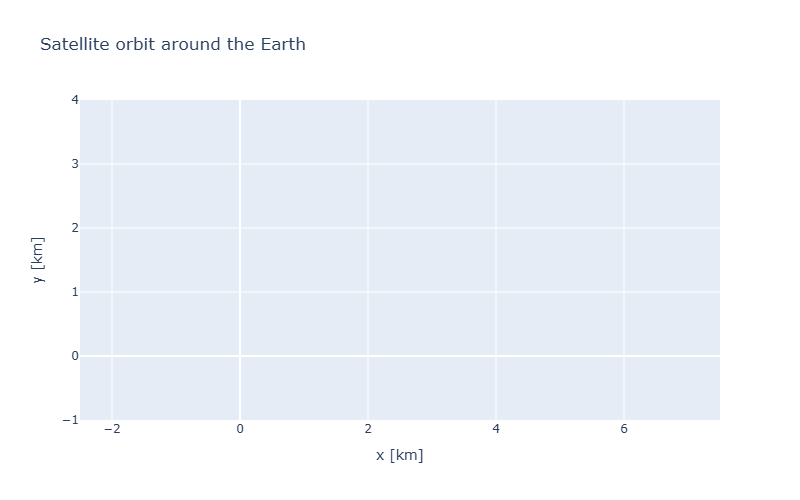

In [15]:
pio.renderers.default = "png"
fig0 = go.Figure()

fig0.update_layout(
    title="Satellite orbit around the Earth",
    xaxis_title="x [km]",
    yaxis_title="y [km]",
    showlegend=True,
    width = 800,
    height = 500,
    xaxis=dict(scaleanchor='y', scaleratio=1),
    yaxis=dict(scaleanchor='x', scaleratio=1),

)

+ To add the orbit described by the satellite, it must first be defined in Cartesian coordinates:

In [16]:
xs = rs * np.cos(thetas)
ys = rs * np.sin(thetas)

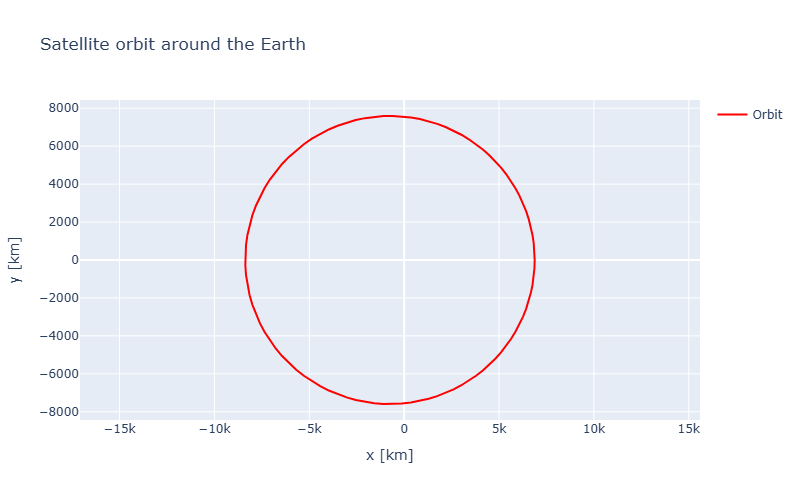

In [17]:
fig0.add_trace(go.Scatter(x=xs, y=ys,
                          mode='lines',
                          name='Orbit',
                          line=dict(color='red')))

+ A representation of the Earth can be added:

In [18]:
x_tierra = r_tierra * np.cos(thetas)
y_tierra = r_tierra * np.sin(thetas)

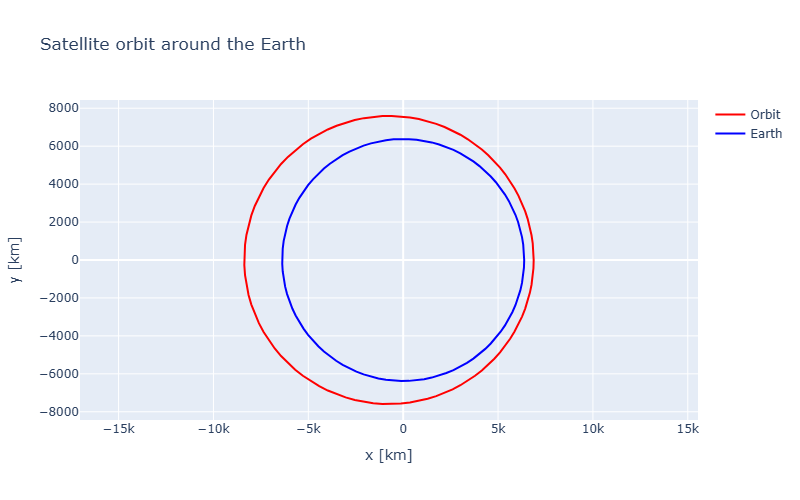

In [19]:
fig0.add_trace(go.Scatter(x=x_tierra, y=y_tierra,
                          mode='lines',
                          name='Earth',
                          line=dict(color='blue')))

+ Representations of perigee and apogee are added:

In [20]:
# Perigee
rp_xs = rp * np.cos(0)
rp_ys = rp * np.sin(0)

# Apogee
ra_xs = ra * np.cos(np.pi)
ra_ys = ra * np.sin(np.pi)

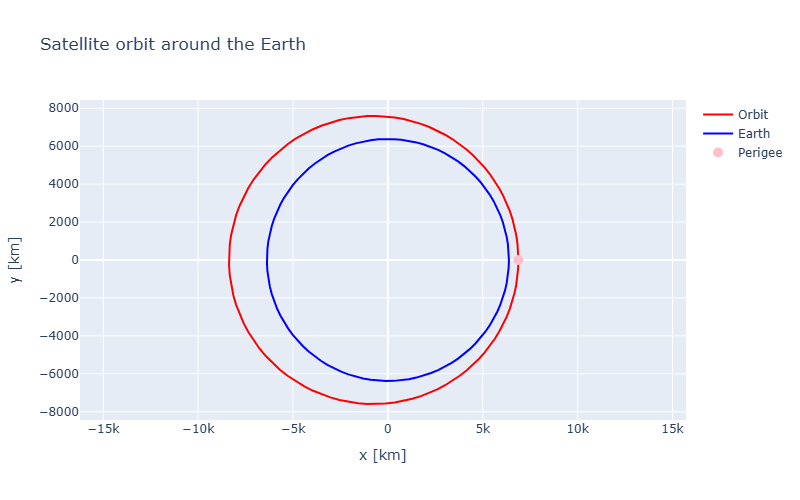

In [21]:
fig0.add_trace(go.Scatter(x=[rp_xs], y=[rp_ys],
                          mode='markers',
                          name='Perigee',
                          marker=dict(color='pink', size=10)))

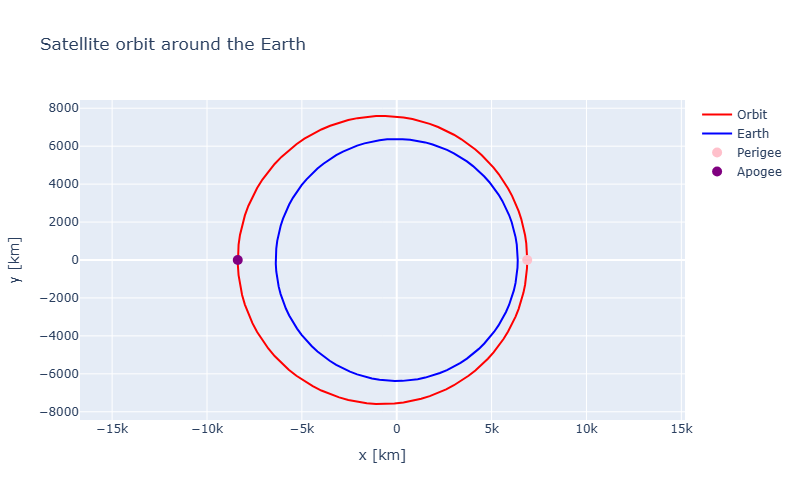

In [22]:
fig0.add_trace(go.Scatter(x=[ra_xs], y=[ra_ys],
                          mode='markers',
                          name='Apogee',
                          marker=dict(color='purple', size=10)))

### Problem 2.37

A meteoroid is first observed approaching the earth when it is 402,000 km from the center of the
 earth with a true anomaly of 150°. If the speed of the meteoroid at that time is 2.23 km/s,
 calculate:
+ the eccentricity of the trajectory;
+ the altitude at closest approach;
+ the speed at the closest approach.

For this problem, it is possible to begin by calculating the specific energy as follows:

$$
ϵ = \frac{1}{2} v^2 - \frac{μ}{r}
$$

+ Definition of the variables given in the problem:

In [23]:
r = 402000                      # In km
v = 2.23                        # In km/s
mu = mu                         # In km^3 / s^2
theta = np.deg2rad(150)         # In rad

Note: The Earth's $\mu$ calculated in the previous problem is reused:

In [24]:
epsilon = 1/2 * v**2 - mu / r

In [25]:
print(f"The specific energy is {epsilon:.3f} km^2/s^2")

The specific energy is 1.495 km^2/s^2


The specific energy is also given by:

$$
ϵ = \frac{-\mu}{2a}
$$

Solving for $a$ gives:

$$
a = - \frac{\mu}{2ϵ}
$$

In [26]:
a = - mu / (2 * epsilon)

In [27]:
print(f"The semimajor axis of the orbit is {a:.3f} km")

The semimajor axis of the orbit is -133319.489 km


Since the semimajor axis is negative, the orbit is hyperbolic.

To find the value of $e$, we can start from angular momentum, where:
$$
\begin{align}
h^2 = μa (1 - e^2)  \\
h^2 = μr (1 + ecosθ)
\end{align}
$$

Equating these expressions gives:

$$
r (1 + ecosθ) - a (1 - e^2) = 0
$$

For this purpose, a function is defined:

In [28]:
def ecuacion_e (e):
  return r * (1 + e * np.cos(theta)) -  a * (1 - e**2)

and *fsolve* from *scipy* is used:

In [29]:
e = fsolve(ecuacion_e, 0.5, xtol=1e-10)

In [30]:
print(f"The orbital eccentricity is {e[0]:.3f}")

The orbital eccentricity is 1.086


This confirms that the orbit is hyperbolic.

To determine the periapsis altitude, use:

$$
r_p = |a|(e -1)
$$

The Earth's radius must also be subtracted:

In [31]:
rp = np.abs(a) * (e[0] - 1)

In [32]:
print(f"The periapsis altitude is {rp - r_tierra:.0f} km")

The periapsis altitude is 5088 km


$$
v = \sqrt{\mu ( \frac{2}{r} + \frac{1}{|a|})}
$$

In [33]:
vp = np.sqrt(mu * (2 / rp + 1 / np.abs(a)))

In [34]:
print(f"The velocity at perigee is {vp:.3f} km/s")

The velocity at perigee is 8.516 km/s


Finally, the orbit is plotted:

+ The figure is created:

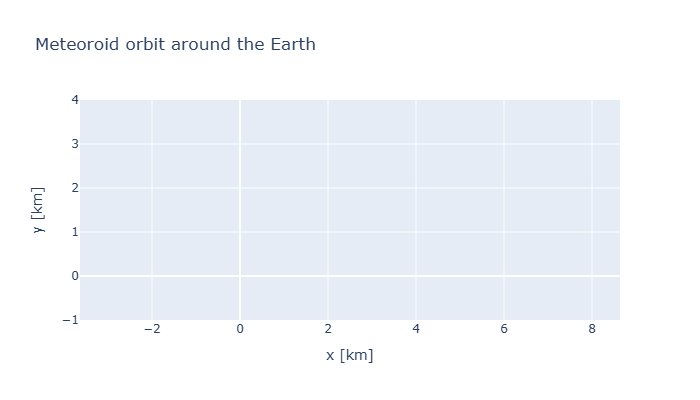

In [35]:
pio.renderers.default = "png"
fig1 = go.Figure()

fig1.update_layout(
    title="Meteoroid orbit around the Earth",
    xaxis_title="x [km]",
    yaxis_title="y [km]",
    showlegend=True,
    width = 700,
    height = 400,
    xaxis=dict(scaleanchor='y', scaleratio=1),
    yaxis=dict(scaleanchor='x', scaleratio=1),

)

+ The orbit is added:

In [36]:
thetas_h = np.linspace(-np.pi/2, np.pi/2, 50)

rs = a * (1 - e**2) / (1 + e * np.cos(thetas_h))

In [37]:
xs = rs * np.cos(thetas_h)
ys = rs * np.sin(thetas_h)

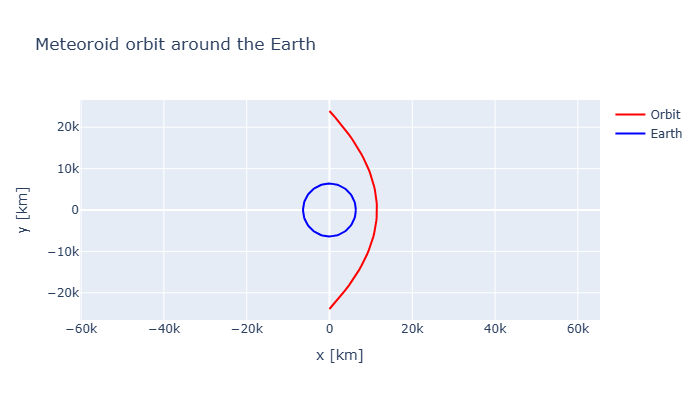

In [38]:
fig1.add_trace(go.Scatter(x=xs, y=ys,
                          mode='lines',
                          name='Orbit',
                          line=dict(color='red')))
fig1.add_trace(go.Scatter(x=x_tierra, y=y_tierra,
                          mode='lines',
                          name='Earth',
                          line=dict(color='blue')))



### Problem 3.9
An Earth-orbiting satellite has a perigee radius of 7000 km and an apogee radius of 10,000 km.
+ What true anomaly $Δθ$ is swept out between $t = 0.5 h$ and $t = 1.5 h$ after perigee passage?
+ What area is swept out by the position vector during that time interval?

Since the problem concerns the orbital trajectory of a satellite around the Earth, the same $\mu$ continues to be used:

In [39]:
mu = mu

First, the values given in the problem are specified: the times and the perigee and apogee radii:

In [40]:
# Times
t1 = 0.5 * 3600     # In seconds
t2 = 1.5 * 3600     # In seconds

In [41]:
# Perigee radius
rp = 7000           # In km

# Apogee radius
ra = 10000          # In km

The semimajor axis is found using:
$$
a = \frac{r_p + r_a}{2}
$$

In [42]:
a = (rp + ra) / 2

Then, the eccentricity is found using:
$$
e = \frac{r_a - r_p}{r_a + r_p}
$$

In [43]:
e = (ra - rp) / (ra + rp)

Finally, the orbital period is calculated as before:

$$
T = 2π \sqrt{\frac{a^3}{μ}}
$$

In [44]:
T = 2 * np.pi * np.sqrt(a**3 / mu)

From this, the values corresponding to the mean anomaly ($M$) and the true anomaly, which will be denoted by ($f$) in this exercise, can be calculated:

The mean anomaly is given by $M = nt$, where $n = \sqrt{a^3 μ}$:

A function is defined to calculate it more easily for each time:

In [45]:
def anomalia_media(t):
  n = np.sqrt(mu / a**3)
  M = n * t
  return M

The functions are called for each time:

In [46]:
M1 = anomalia_media(t1)
M2 = anomalia_media(t2)

In [47]:
print(f"The mean anomaly at time t1 is {np.rad2deg(M1):.2f}°")
print(f"The mean anomaly at time t2 is {np.rad2deg(M2):.2f}°")

The mean anomaly at time t1 is 83.09°
The mean anomaly at time t2 is 249.26°


The eccentric anomaly can also be found using the *newton* module, knowing that:

$$
M = E - esin(E)
$$

In [48]:
def funcion_kepler(E, e, M):
  return E - e * np.sin(E) - M

In [49]:
E1 = newton(funcion_kepler, M1, args=(e, M1))
E2 = newton(funcion_kepler, M2, args=(e, M2))

In [50]:
print(f"The eccentric anomaly at time t1 is {np.rad2deg(E1):.2f}°")
print(f"The eccentric anomaly at time t2 is {np.rad2deg(E2):.2f}°")

The eccentric anomaly at time t1 is 93.18°
The eccentric anomaly at time t2 is 240.47°


The true anomaly is expressed in terms of the mean anomaly and eccentricity as follows:

$$
f = M + 2esin(M)
$$

In [51]:
def anomalia_verdadera(M):
  f = M + 2 * e * np.sin(M)
  return f

In [52]:
f1 = anomalia_verdadera(M1)
f2 = anomalia_verdadera(M2)

In [53]:
print(f"The true anomaly at time t1 is {np.rad2deg(f1):.2f}°")
print(f"The true anomaly at time t2 is {np.rad2deg(f2):.2f}°")

The true anomaly at time t1 is 103.16°
The true anomaly at time t2 is 230.35°


The change in true anomaly over the given time interval must be calculated:

In [54]:
delta_f = f2 - f1

In [55]:
print(f"The change in true anomaly is {np.rad2deg(delta_f):.2f}°")

The change in true anomaly is 127.19°


Finally, the total swept area along the trajectory is:

$$
A_{total} = π a b
$$
where $b = \sqrt{1 - e^2}$, so:

$$
A_{total} = π a^2 \sqrt{1 - e^2}
$$

In [56]:
area_total = np.pi * a**2 * (np.sqrt(1 - e**2))

Thus, the swept area depends on the total area, the travel time, and the orbital period as follows:

$$
A_{swept} = A_{total} \frac{t_2 - t_1}{T}
$$

In [57]:
area_barrida = area_total * (t2 - t1) / T

In [58]:
print(f"The swept area was {area_barrida:.2e} km^2")

The swept area was 1.03e+08 km^2


### Problem 3.17

 A trajectory has a perigee velocity 1.1vesc and a perigee altitude of 200 km. If at 10 a.m. the satellite is traveling toward the earth with a speed of 8 km/s, how far will it be from the earth’s surface at 5 p.m. the same day?

First, the values stated in the problem are defined, reusing those from earlier sections that are still applicable:

In [59]:
# Values used previously
r_tierra = r_tierra
mu = mu
thetas_h = thetas_h

In [60]:
# Problem data
rp = 200 + r_tierra       # In km
t = 7 * 3600              # In seconds (s)

With these data, the satellite's escape velocity can be calculated:

$$
v_{esc} = \sqrt{ \frac{2μ}{r_p} }
$$

In [61]:
v_esc = np.sqrt((2 * mu) / rp )

Therefore, the escape velocity at perigee is:
$$
v_p = 1.1 v_{esc} = 1.1 * \sqrt{ \frac{2μ}{r_p} }
$$

In [62]:
vp = 1.1 * v_esc

In [63]:
print(f"The velocity at perigee is {vp:.2f} km/s")

The velocity at perigee is 12.11 km/s


Next, the specific mechanical energy is calculated to subsequently determine the semimajor axis:

$$
ϵ = \frac{1}{2} v_p^2 - \frac{μ}{r_p}
$$

In [64]:
epsilon = 1/2 * (vp**2) - mu / rp

Since energy is also defined as:

$$
ϵ = \frac{\mu}{2 a}
$$

The semimajor axis is isolated:
$$
a = \frac{\mu}{2 ϵ}
$$

In [65]:
a = mu / (2 * epsilon)

In [66]:
print(f"The semimajor axis is {a:.2f} km")

The semimajor axis is 15661.90 km


The eccentricity is then calculated:

$$
e = \frac{r_p}{a} + 1
$$

In [67]:
e = (rp / a) + 1

In [68]:
print(f"The eccentricity is {e:.3f}")

The eccentricity is 1.420


This corresponds to a hyperbolic orbit.

For hyperbolas, Kepler's equation is given by:

$$
\sqrt{\frac{μ}{|a|^3}} (t - t_p) = esinh(F) - F
$$

Therefore, a function is defined to find the hyperbolic eccentric anomaly and it is solved using *fsolve*:

In [69]:
def ecuacion_F(F):
  return ((a**3 / mu)**0.5) * (e * np.sinh(F) - F) - t

In [70]:
F = fsolve(ecuacion_F, 1, xtol=1e-10)

In [71]:
print(f"The eccentric anomaly is {F[0]:.2f} rad")

The eccentric anomaly is 2.73 rad


From this, it is possible to calculate the distance at which the satellite will be:

$$
r = a(ecosh(F) - 1)
$$

In [72]:
r = a * (e  * np.cosh(F[0]) - 1)

In [73]:
print(f"The satellite will be {r - r_tierra:.0f} km away")

The satellite will be 149307 km away


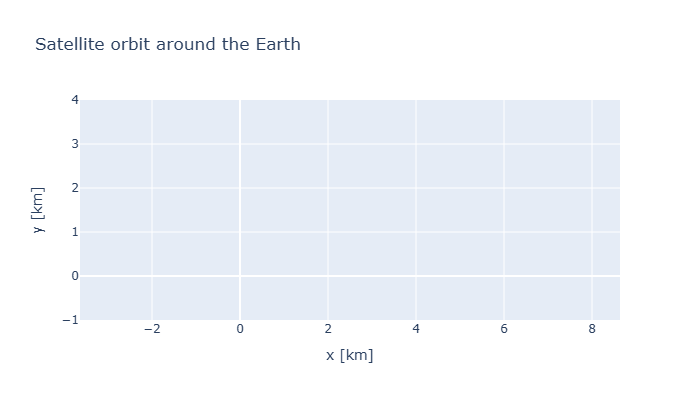

In [74]:
pio.renderers.default = "png"
fig2 = go.Figure()

fig2.update_layout(
    title="Satellite orbit around the Earth",
    xaxis_title="x [km]",
    yaxis_title="y [km]",
    showlegend=True,
    width = 700,
    height = 400,
    xaxis=dict(scaleanchor='y', scaleratio=1),
    yaxis=dict(scaleanchor='x', scaleratio=1),

)

In [75]:
rs = a * (1 - e**2) / (1 + e * np.cos(thetas_h))

In [76]:
xs = rs * np.cos(thetas_h)
ys = rs * np.sin(thetas_h)

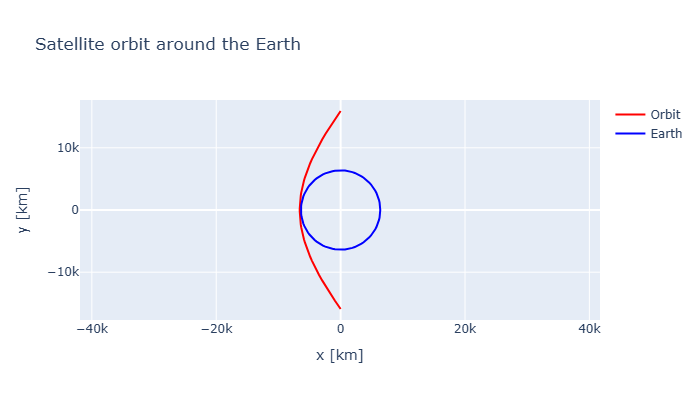

In [77]:
fig2.add_trace(go.Scatter(x=xs, y=ys,
                          mode='lines',
                          name='Orbit',
                          line=dict(color='red')))
fig2.add_trace(go.Scatter(x=x_tierra, y=y_tierra,
                          mode='lines',
                          name='Earth',
                          line=dict(color='blue')))



### Problem 4.15

At time $t_0$ (relative to perigee passage), a spacecraft has the following orbital parameters:

+ $e = 1.5$
+ $perigee \thinspace altitude = 300 km$
+ $i = 35°$
+ $\Omega = 130°$
+ $ω = 115°$

Calculate $ \vec{r}$ and $\vec{v}$ at perigee relative to:

+ The perifocal reference frame.
+ The geocentric equatorial frame.

In [78]:
# Values used previously
r_tierra = r_tierra
mu = mu
thetas_h = thetas_h

In [79]:
# Problem data
rp = 300 + r_tierra
e = 1.5
I = np.deg2rad(35)
O = np.deg2rad(130)
w = np.deg2rad(115)

The semimajor axis is calculated first:
$$
a = \frac{r_p}{1 - e}
$$

In [80]:
a = rp / (1 - e)

With the perigee radius, the perigee velocity can be calculated using the function defined in *Problem 2.22*:

In [81]:
vp = vels(rp)

The position at perigee must be represented as a vector:

In [82]:
r_peri = np.array([rp, 0, 0])

In [83]:
print(f"The position vector in the perifocal system is {r_peri[0]}p"
      f" + {r_peri[1]}q + {r_peri[2]}w km")

The position vector in the perifocal system is 6678p + 0q + 0w km


Velocity is perpendicular to position and tangent to the trajectory; therefore, at perigee the velocity is in the direction $\hat q$, tangent to the trajectory in the $P-Q$ plane:

In [84]:
v_peri = np.array([0, vp, 0])

In [85]:
print(f"The velocity vector in the perifocal system is {v_peri[0]}p"
      f" + {v_peri[1]:.2f}q + {v_peri[2]}w km/s")

The velocity vector in the perifocal system is 0.0p + 12.22q + 0.0w km/s


To convert to the astronomical system, it is necessary to use the inverse of the rotation matrix ($M$):

$$
M^{-1} = R_z(-Ω) R_x(-i) R_z(-ω)
$$

These rotations are initially computed:

In [86]:
RzmO = spy.rotate(-O, 3)
Rxmi = spy.rotate(-I, 1)
Rzmw = spy.rotate(-w, 3)

Then, the matrix is calculated:

In [87]:
M = spy.mxm(RzmO, spy.mxm(Rxmi, Rzmw))

With the matrix and the position and velocity values in the perifocal system, these quantities are determined in the astronomical system:

$$
\begin{bmatrix}
x \\
y \\
z
\end{bmatrix}
= R_z(-Ω) R_x(-i) R_z(-ω)
\begin{bmatrix}
x''' \\
y''' \\
z'''
\end{bmatrix}
= M^{-1}
\begin{bmatrix}
x''' \\
y''' \\
z'''
\end{bmatrix}
$$

$$
\begin{bmatrix}
v_x \\
v_y \\
V_z
\end{bmatrix}
= M^{-1}
\begin{bmatrix}
v_x''' \\
v_y''' \\
v_z'''
\end{bmatrix}
$$

In [88]:
# Position in the astronomical system
r_astro = spy.mxv(M, r_peri)

# Velocity in the astronomical system
v_astro = spy.mxv(M, v_peri)

In [89]:
print(f"The position vector in the astronomical system is {r_astro[0]:.0f}i"
      f" {r_astro[1]:.0f}j + {r_astro[2]:.0f}k km")

The position vector in the astronomical system is -1984i -5349j + 3471k km


In [90]:
print(f"The velocity vector in the astronomical system is {v_astro[0]:.2f}i"
      f" {v_astro[1]:.3f}j {v_astro[2]:.3f}k")

The velocity vector in the astronomical system is 10.36i -5.763j -2.961k


For the plot, the lists and matrices are defined:

In [91]:
thetas_h = thetas_h
r_astros = np.zeros((len(thetas_h), 3))

The orbit is constructed for plotting:

In [92]:
for i, thetas_h in enumerate(thetas_h):
  r = (a * (1 - e**2) / (1 + e * np.cos(thetas_h)))

  # Coordinates in the perifocal system
  xppp = r * np.cos(thetas_h)
  yppp = r * np.sin(thetas_h)
  zppp = 0

  r_peris = np.array([xppp, yppp, zppp])

  # Coordinates in the astronomical system
  r_astros[i] = spy.mxv(M, r_peris)

The variables used to plot the representation of the Earth are defined:

In [93]:
alpha, beta = np.linspace(0, 2 * np.pi, 100), np.linspace(0, np.pi, 100)
x0 = r_tierra * np.outer(np.cos(alpha), np.sin(beta))
y0 = r_tierra * np.outer(np.sin(alpha), np.sin(beta))
z0 = r_tierra * np.outer(np.ones(np.size(alpha)), np.cos(beta))

The figure and its layout are created:

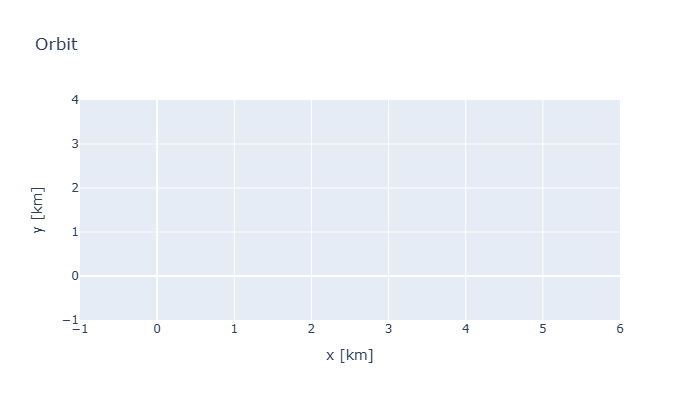

In [94]:
pio.renderers.default = "png"
fig3 = go.Figure()

fig3.update_layout(
    title="Orbit",
    xaxis_title="x [km]",
    yaxis_title="y [km]",
    showlegend=True,
    scene=dict(aspectmode='data'),
    width = 700,
    height = 400
    )

The orbit is added:

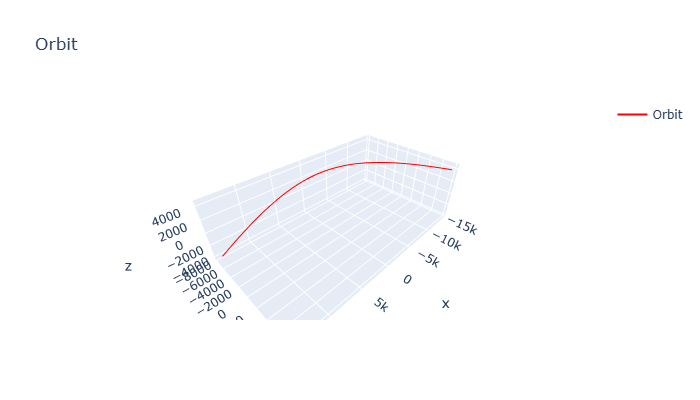

In [95]:
fig3.add_trace(go.Scatter3d(x=r_astros[:,0],
                            y=r_astros[:,1],
                            z=r_astros[:,2],
                            mode='lines',
                            name='Orbit',
                            line=dict(color='red')
                            ))

The representation of the Earth is added:

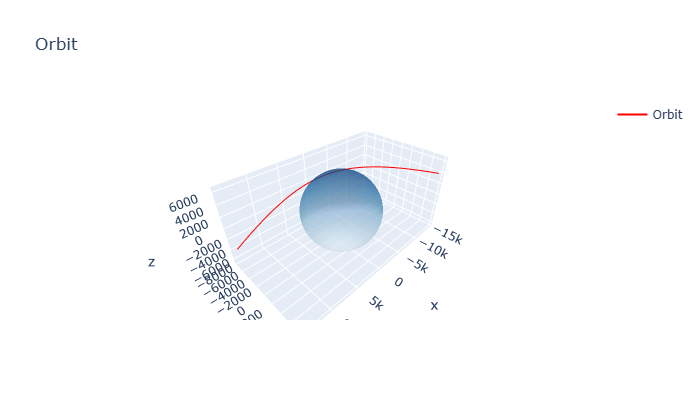

In [96]:
fig3.add_trace(go.Surface(
    x=x0,
    y=y0,
    z=z0,
    showscale=False,
    colorscale='Blues',
    opacity=0.5,
    name='Earth'
))

### Problem 2.45
Relative to an Earth-centered, nonrotating frame, the position and velocity vectors of a spacecraft are $\vec r_0 = 6320 \hat i +7750 \hat k (km)$ and $\vec v_0 = 11 \hat j (km/s)$.
+ Find the position vector 10 min later.
+ Calculate the change in true anomaly over the 10-min time span.

In [97]:
# Values used previously
mu = mu

In [98]:
# Problem data
r0_vec = np.array([6320, 0, 7750])        # In km
v0_vec = np.array([0, 11, 0])             # In km
delta_t = 10 * 60                         # In seconds (s)

With the position and velocity vectors, the main orbital parameters can be found directly:

$$
\begin{align}
\dot r = \frac{\vec v \cdot \vec r}{r} \\
\vec h = \vec r \times \vec v \\
\vec e = \frac{\vec v \times \vec h}{μ} - \frac{\vec r}{r}\\
p = \frac{h^2}{μ}\\
a = \frac{p}{1 - e^2}\\
α = \frac{1}{a}
\end{align}
$$

A function is defined for use in the following problems where these parameters are also needed:

In [99]:
def parametros_orbitales(r0_vec, v0_vec):

  r0 = np.linalg.norm(r0_vec)
  v0 = np.linalg.norm(v0_vec)

  rdot0 = (v0_vec @ r0_vec) / r0

  h_vec = np.cross(r0_vec, v0_vec)
  h = np.linalg.norm(h_vec)

  e_vec = np.cross(v0_vec, h_vec) / mu - r0_vec / r0
  e = np.linalg.norm(e_vec)

  p = h**2 / mu
  a = p / (1 - e**2)

  alfa = 1 / a

  return r0, v0, rdot0, h, h_vec, e, e_vec, p, a, alfa


The function is called:

In [100]:
r0, v0, rdot0, h, h_vec, e, e_vec, p, a, alfa = parametros_orbitales(r0_vec, v0_vec)

In [101]:
print(f"The value of r is {r0:.2f} km")
print(f"The value of v is {v0:.2f} km/s")
print(f"The value of rdot is {rdot0:.2f} km/s")
print(f"The value of h is {h:.2f} km^2/s")
print(f"The value of e is {e:.3f}")
print(f"The value of p is {p:.2f} km")
print(f"The value of a is {a:.2f} km")
print(f"The value of alpha is {alfa:.2f}")

The value of r is 10000.24 km
The value of v is 11.00 km/s
The value of rdot is 0.00 km/s
The value of h is 110002.69 km^2/s
The value of e is 2.036
The value of p is 30357.70 km
The value of a is -9655.58 km
The value of alpha is -0.00


Based on this, the eccentric anomaly for hyperbolas is found:

$$
F = cos^{-1} \frac{\frac{r}{|a|} - 1}{e}
$$

In [102]:
F0 = np.arccosh(((r0 / np.abs(a)) + 1) / e)

The perigee radius is then calculated to confirm that the particle is there:
$$
r_p = |a|(e-1)
$$

In [103]:
rp = np.abs(a) * (e - 1)

In [104]:
print(f"The perigee radius is {rp:.2f} km and the particle is at {r0:.2f} km")

The perigee radius is 10000.24 km and the particle is at 10000.24 km


This confirms that it is at perigee.

Next, the value of the universal variable at the initial point is calculated:

In [105]:
x0 = np.sqrt(np.abs(a)) * F0

To determine the final value of the universal variable, the universal Kepler equation must be solved:

$$
\sqrt{\mu} (t-t_0)=\frac{r_0 \dot{r}_0}{\sqrt{\mu}} x^2 C\left(\alpha x^2\right)+\left(1-\alpha r_0\right) x^3 S\left(\alpha x^2\right)+r_0 x
$$

For this reason, a function is defined and solved with *newton*:

In [106]:
def kepler_universal(x, r0, rdot0, mu, alfa, delta_t):
  fx = (r0 * rdot0 / np.sqrt(mu)) * (x**2) * extra.C(alfa * x**2) + \
       (1 - alfa * r0) * (x**3) * extra.S(alfa * x**2) + r0 * x - \
       np.sqrt(mu) * delta_t
  return fx

In [107]:
x = newton(kepler_universal, 1, args=(r0, rdot0, mu, alfa, delta_t))

From this, the final eccentric anomaly is calculated:

$$
F = \frac{x}{\sqrt{|a|}} + F_0
$$

In [108]:
F = x / np.sqrt(np.abs(a)) + F0

Then, the position is calculated:

$$
r = |a| e cosh(F) - 1
$$

In [109]:
r = np.abs(a) * (e * np.cosh(F) - 1)

Next, the Lagrange coefficients are used to correctly determine the final positions and velocities:

$$
\begin{aligned}
f&=1-\frac{x^2}{r_0} C\left(\alpha x^2\right) \\
g&=\Delta t-\frac{1}{\sqrt{\mu}} x^3 S\left(\alpha x^2\right) \\
\dot{f}&=\frac{\sqrt{\mu}}{r r_0}\left[\alpha x^3 S\left(\alpha x^2\right)-x\right] \\
\dot{g}&=1-\frac{x^2}{r} C\left(\alpha x^2\right)
\end{aligned}
$$

A function is defined:

In [110]:
def coef_lagrange(x, alfa, mu, r0, r, delta_t):
  f = 1 - (x**2 / r0) * extra.C(alfa * x**2)
  g = delta_t - (1 / np.sqrt(mu)) * (x**3) * extra.S(alfa * x**2)

  fdot = (np.sqrt(mu) / (r * r0))*((alfa * x**3)*extra.S(alfa * x**2) - x)
  gdot = 1 - (x**2 / r) * extra.C(alfa * x**2)

  return f, g, fdot, gdot

The function is called:

In [111]:
f, g, fdot, gdot = coef_lagrange(x, alfa, mu, r0, r, delta_t)

In [112]:
print(f"f = {f:.2f}")
print(f"g = {g:.2f}")
print(f"fdot = {fdot:.2f}")
print(f"gdot = {gdot:.2f}")

f = 0.93
g = 587.34
fdot = -0.00
gdot = 0.94


Finally, the final positions and velocities are determined:
$$
\begin{align}
\vec r = f \thinspace \vec r_0 + g \thinspace \vec v_0\\
\vec v = \dot f \thinspace \vec r_0 + \dot g \thinspace \vec v_0 \\
\end{align}
$$

A function is defined:

In [113]:
def posiciones_finales(f, g, fdot, gdot, r0_vec, v0_vec):
  r_vec = f * r0_vec + g * v0_vec
  v_vec = fdot * r0_vec + gdot * v0_vec

  return r_vec, v_vec

The function is called for the vectors, and their magnitudes are found:

In [114]:
r_vec_final, v_vec_final = posiciones_finales(f, g, fdot, gdot, r0_vec, v0_vec)

In [115]:
r_final = np.linalg.norm(r_vec_final)
v_final = np.linalg.norm(v_vec_final)

In [116]:
print(f"The position vector is {r_vec_final[0]:.0f}i"
      f" + {r_vec_final[1]:.0f}j + {r_vec_final[2]:.0f}k km")

The position vector is 5900i + 6461j + 7235k km


In [117]:
print(f"The velocity vector is {v_vec_final[0]:.2f}i"
      f" + {v_vec_final[1]:.2f}j  {v_vec_final[2]:.2f}k km")

The velocity vector is -1.30i + 10.36j  -1.60k km


In [118]:
delta_theta = np.arccos(np.dot(r_vec_final / r_final , r0_vec / r0))

In [119]:
print(f"The change in true anomaly was "
      f"{np.rad2deg(delta_theta):.1f} ° ")

The change in true anomaly was 34.7 ° 


For the plot, the lists containing the angles and coordinates are defined:

In [120]:
thetas_final = np.linspace(-delta_theta, delta_theta, 100)
r_finals = a * (1 - e**2) / (1 + e * np.cos(thetas_final))

xs = r_finals * np.cos(thetas_final)
ys = r_finals * np.sin(thetas_final)
zs = np.zeros_like(xs)

In [121]:
alpha, beta = np.linspace(0, 2 * np.pi, 100), np.linspace(0, np.pi, 100)
x0 = r_tierra * np.outer(np.cos(alpha), np.sin(beta))
y0 = r_tierra * np.outer(np.sin(alpha), np.sin(beta))
z0 = r_tierra * np.outer(np.ones(np.size(alpha)), np.cos(beta))

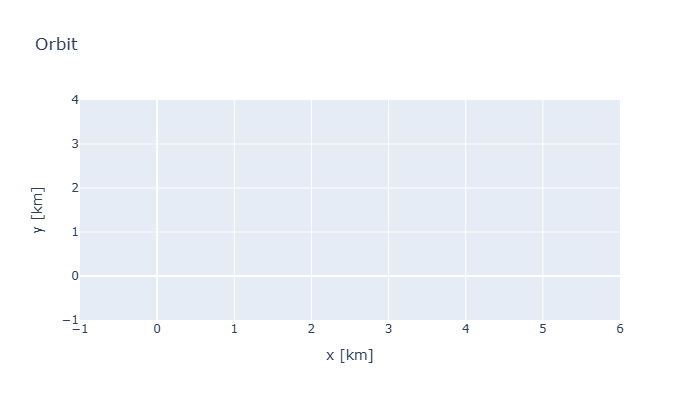

In [122]:
pio.renderers.default = "png"
fig4 = go.Figure()

fig4.update_layout(
    title="Orbit",
    xaxis_title="x [km]",
    yaxis_title="y [km]",
    showlegend=True,
    scene=dict(aspectmode='data'),
    width = 700,
    height = 400
    )

The orbit and the representation of the Earth are added.

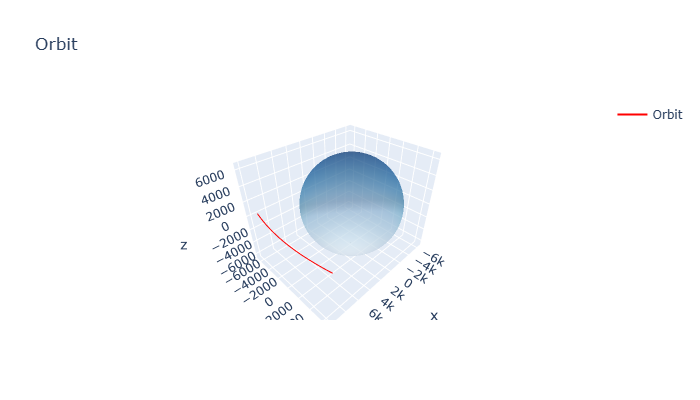

In [123]:
# Trajectory
fig4.add_trace(go.Scatter3d(
    x=xs,
    y=ys,
    z=zs,
    mode='lines',
    name='Orbit',
    line=dict(color='red')
))

# Representation of the Earth
fig4.add_trace(go.Surface(
    x=x0,
    y=y0,
    z=z0,
    showscale=False,
    colorscale='Blues',
    opacity=0.5,
))

### Problem 4.4

At a given instant, the position $\vec{r}$ and velocity $\vec{v}$ of a satellite in the geocentric equatorial frame are:

$$
\vec{r} = 13{,}000\,\hat{k} \quad \text{km}
$$

$$
\vec{v} = 4\,\hat{\imath} + 5\,\hat{\jmath} + 6\,\hat{k} \quad \text{km/s}
$$

**Find:** The classical orbital elements.

In [124]:
# Values used previously
mu = mu

In [125]:
# Problem data
r_vec = np.array([0, 0, -13000])
v_vec = np.array([4, 5, 6])

The function created in Problem $2.45$ is called to obtain the orbital parameters:

In [126]:
r, v, rdot, h, h_vec, e, e_vec, p, a, alfa = parametros_orbitales(r_vec, v_vec)

The vector $\vec n$ and its magnitude are then calculated:

$$
\vec n = \hat e_z \times \vec h
$$

In [127]:
n_vec = np.cross(np.array([0, 0, 1]), h_vec)
n = np.linalg.norm(n_vec)

In [128]:
print(f"The value of r is {r:.2f} km")
print(f"The value of v is {v:.2f} km/s")
print(f"The value of rdot is {rdot:.2f} km/s")
print(f"The value of h is {h:.2f} km^2/s")
print(f"The value of e is {e:.3f}")
print(f"The value of p is {p:.2f} km")
print(f"The value of a is {a:.2f} km")
print(f"The value of alpha is {alfa:.2f}")
print(f"The value of n is {n:.2f} km")

The value of r is 13000.00 km
The value of v is 8.77 km/s
The value of rdot is -6.00 km/s
The value of h is 83240.62 km^2/s
The value of e is 1.298
The value of p is 17383.32 km
The value of a is -25426.03 km
The value of alpha is -0.00
The value of n is 83240.62 km


Next, the orbital inclination angle, right ascension of the ascending node, argument of periapsis, and true anomaly are calculated (in this exercise, the latter is treated as $f$):

$$
\begin{align}
i = cos^{-1} \frac{\vec h \cdot \hat a_z}{h}\\
\Omega = cos^{-1} \frac{\vec n \cdot \hat a_x}{n}\\
ω = cos^{-1} \frac{\vec n \cdot \vec e}{ne}\\
f = cos^{-1} \frac{\vec e \cdot \vec r}{er}
\end{align}
$$

To calculate these same angles in other problems, a function is defined:

In [129]:
def angulos (r_vec, v_vec, h_vec, e_vec, n_vec, r, h, e, n):

  # Orbital inclination
  cosI = h_vec @ np.array([0, 0, 1]) / h
  I = np.arccos(cosI)

  # Right ascension of the ascending node
  cosO = n_vec @ np.array([1, 0, 0]) / n
  Op = np.arccos(cosO)

  if n_vec[1] > 0:
    O = Op
  else:
    O = 2 * np.pi - Op

  # Argument of periapsis
  cosw = e_vec @ n_vec / (e * n)
  wp = np.arccos(cosw)

  if e_vec[2] > 0:
    w = wp
  else:
    w = 2 * np.pi - wp

  # True anomaly
  cosf = r_vec @ e_vec / (r * e)
  fp = np.arccos(cosf)

  if (r_vec @ v_vec) / r > 0:
    f = fp
  else:
    f = 2 * np.pi - fp

  return I, O, w, f

The function is called:

In [130]:
I, O, w, f = angulos(r_vec, v_vec, h_vec, e_vec, n_vec, r, h, e, n)

In [131]:
print(f"The orbital inclination is {np.rad2deg(I):.1f}°")
print(f"The right ascension of the ascending node is {np.rad2deg(O):.1f}°")
print(f"The argument of periapsis is {np.rad2deg(w):.1f}°")
print(f"The true anomaly is {np.rad2deg(f):.1f}°")

The orbital inclination is 90.0°
The right ascension of the ascending node is 51.3°
The argument of periapsis is 344.9°
The true anomaly is 285.1°


Again, it is necessary to find the rotation matrix, but this time *spy.eul2m* is used to verify that it is also a functional method:

In [132]:
M = spy.eul2m(-O, -I, -w, 3,  1,  3)

As before, the lists and matrices needed for plotting are defined:

In [133]:
thetas_h = np.linspace(-np.pi/2, np.pi/2, 50)
rs = np.zeros((len(thetas_h), 3))

In [134]:
for i, thetas_h in enumerate(thetas_h):
  r = (a * (1 - e**2) / (1 + e * np.cos(thetas_h)))

  # Coordinates in the perifocal system
  xppp = r * np.cos(thetas_h)
  yppp = r * np.sin(thetas_h)
  zppp = 0

  r_peris = np.array([xppp, yppp, zppp])

  # Coordinates in the astronomical system
  rs[i] = spy.mxv(M, r_peris)

In [135]:
alpha, beta = np.linspace(0, 2 * np.pi, 100), np.linspace(0, np.pi, 100)
x0 = r_tierra * np.outer(np.cos(alpha), np.sin(beta))
y0 = r_tierra * np.outer(np.sin(alpha), np.sin(beta))
z0 = r_tierra * np.outer(np.ones(np.size(alpha)), np.cos(beta))

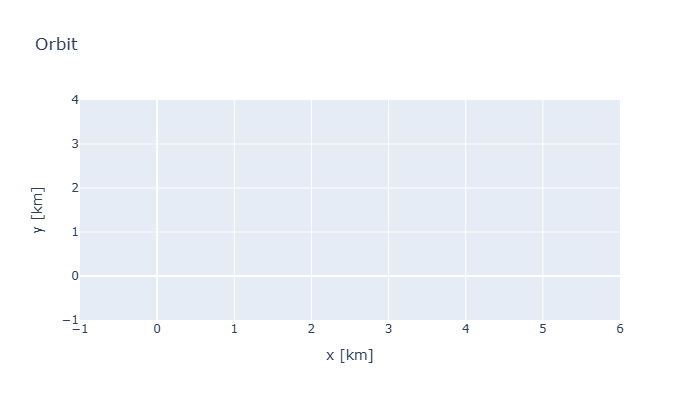

In [136]:
pio.renderers.default = "png"
fig5 = go.Figure()

fig5.update_layout(
    title="Orbit",
    xaxis_title="x [km]",
    yaxis_title="y [km]",
    showlegend=True,
    scene=dict(aspectmode='data'),
    width = 700,
    height = 400
)

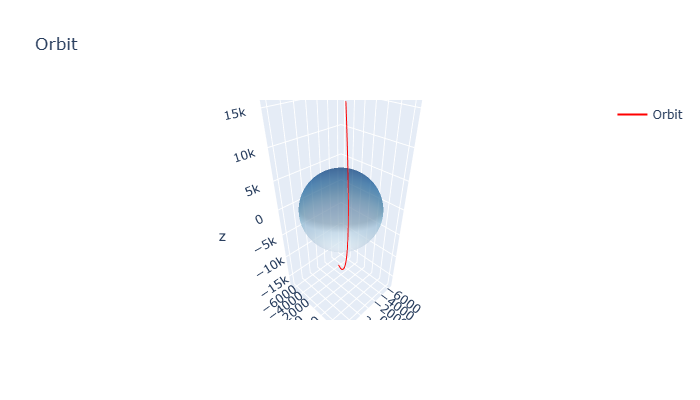

In [137]:
# Trajectory
fig5.add_trace(go.Scatter3d(x=rs[:,0],
                            y=rs[:,1],
                            z=rs[:,2],
                            mode='lines',
                            name='Orbit',
                            line=dict(color='red')
                            ))

# Representation of the Earth
fig5.add_trace(go.Surface(
    x=x0,
    y=y0,
    z=z0,
    showscale=False,
    colorscale='Blues',
    opacity=0.5,
))

### Problem 4.5

At time $t_0$ (relative to perigee passage), the position $\vec{r}$ and velocity $\vec{v}$ of a satellite in the geocentric equatorial frame are:

$$
\vec{r} = 6500\,\hat{\imath} + 7500\,\hat{\jmath} + 2500\,\hat{k} \quad \text{km}
$$

$$
\vec{v} = 4\,\hat{\imath} + 3\,\hat{\jmath} + 3\,\hat{k} \quad \text{km/s}
$$

**Find:** The classical orbital elements.

In [138]:
# Values used previously
mu = mu

In [139]:
# Problem data
r_vec = np.array([6500, -7500, -2500])
v_vec = np.array([4, 3, -3])

The function defined in Problem $2.45$ is called again:

In [140]:
r, v, rdot, h, h_vec, e, e_vec, p, a, alfa = parametros_orbitales(r_vec, v_vec)

In [141]:
print(f"The eccentricity is {e:.2f} ")
print(f"The angular momentum h is {h:.2f} km^2/s")

The eccentricity is 0.22 
The angular momentum h is 58655.78 km^2/s


The vector $\vec n$ is found as in the previous problem:

In [142]:
n_vec = np.cross(np.array([0, 0, 1]), h_vec)
n = np.linalg.norm(n_vec)

Likewise, the function for determining the angles is called from the previous problem:

In [143]:
I, O, w, f = angulos(r_vec, v_vec, h_vec, e_vec, n_vec, r, h, e, n)

In [144]:
print(f"The orbital inclination is {np.rad2deg(I):.1f}°")
print(f"The right ascension of the ascending node is {np.rad2deg(O):.1f}°")
print(f"The argument of periapsis is {np.rad2deg(w):.1f}°")
print(f"The true anomaly is {np.rad2deg(f):.1f}°")

The orbital inclination is 32.4°
The right ascension of the ascending node is 107.6°
The argument of periapsis is 72.4°
The true anomaly is 134.7°


The rotation matrix must also be found, but in this case the rotations are initially operated, as was done in Problem $4.15$:

In [145]:
RzmO = spy.rotate(-O, 3)
Rxmi = spy.rotate(-I, 1)
Rzmw = spy.rotate(-w, 3)

In [146]:
M = spy.mxm(RzmO, spy.mxm(Rxmi, Rzmw))

Similarly, the necessary lists and matrices are defined:

In [147]:
thetas_h = np.linspace(-np.pi/2, np.pi/2, 50)
rs = np.zeros((len(thetas_h), 3))

In [148]:
for i, thetas_h in enumerate(thetas_h):
  r = (a * (1 - e**2) / (1 + e * np.cos(thetas_h)))

  # Coordinates in the perifocal system
  xppp = r * np.cos(thetas_h)
  yppp = r * np.sin(thetas_h)
  zppp = 0

  r_peris = np.array([xppp, yppp, zppp])

  # Coordinates in the astronomical system
  rs[i] = spy.mxv(M, r_peris)

In [149]:
alpha, beta = np.linspace(0, 2 * np.pi, 100), np.linspace(0, np.pi, 100)
x0 = r_tierra * np.outer(np.cos(alpha), np.sin(beta))
y0 = r_tierra * np.outer(np.sin(alpha), np.sin(beta))
z0 = r_tierra * np.outer(np.ones(np.size(alpha)), np.cos(beta))

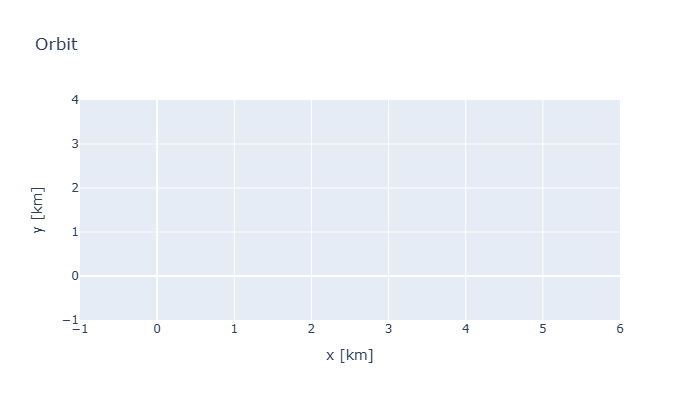

In [150]:
pio.renderers.default = "png"
fig6 = go.Figure()

fig6.update_layout(
    title="Orbit",
    xaxis_title="x [km]",
    yaxis_title="y [km]",
    showlegend=True,
    scene=dict(aspectmode='data'),
    width = 700,
    height = 400
)

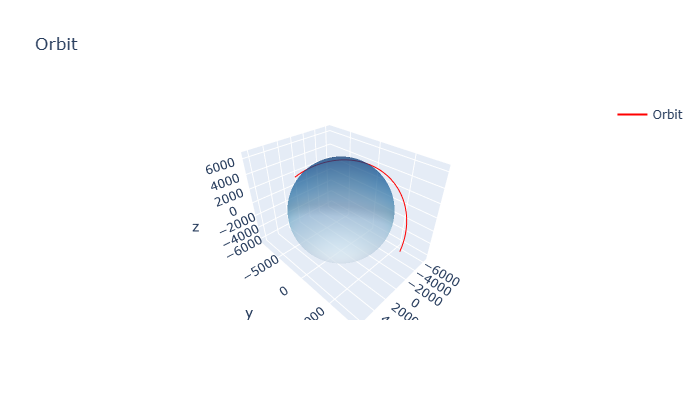

In [151]:
# Trajectory
fig6.add_trace(go.Scatter3d(x=rs[:,0],
                            y=rs[:,1],
                            z=rs[:,2],
                            mode='lines',
                            name='Orbit',
                            line=dict(color='red')
                            ))

# Representation of the Earth
fig6.add_trace(go.Surface(
    x=x0,
    y=y0,
    z=z0,
    showscale=False,
    colorscale='Blues',
    opacity=0.5,
))

### Problem 4.11

Define the rotation matrix $(M)$ as:

$$
\begin{equation}
\begin{matrix}
M_{11} & M_{12} & M_{13} \\
M_{21} & M_{22} & M_{23} \\
M_{31} & M_{32} & M_{33}
\end{matrix}
\end{equation}
$$

From this, the angles $α, β, γ$ of the Euler rotation sequence can be determined using:

$$
\begin{align}
α = tan^{-1} (\frac{-M_{31}}{M_{32}})  (0  \leq α \leq 360°) \\
β = cos^{-1} (M_{33})  (0 \leq β \leq 180°) \\
γ = tan^{-1} (\frac{M_{13}}{M_{23}})  (0 \leq γ \leq 360°)
\end{align}
$$

For the yaw, pitch, and roll sequence:

$$
\begin{align}
α = tan^{-1} (\frac{M_{12}}{M_{11}})  (0  \leq α \leq 360°) \\
β = sin^{-1} (-M_{13})  (-90° \leq β \leq 90°) \\
γ = tan^{-1} (\frac{M_{23}}{M_{33}})  (0 \leq γ \leq 360°)
\end{align}
$$

The matrix presented in the problem is defined:

In [152]:
M = np.array([[0.086824, -0.77768, 0.62264],
              [-0.49240, -0.57682, -0.65178],
              [0.86603, -0.25000, -0.43301]])

+ Classical Euler sequence:

In [153]:
alpha = np.arctan((-M[2, 0]) / M[2, 1])

In [154]:
print(f"The alpha angle in the Euler sequence is {np.rad2deg(alpha):.2f}°")

The alpha angle in the Euler sequence is 73.90°


In [155]:
beta = np.arccos(M[2, 2])

In [156]:
print(f"The beta angle in the Euler sequence is {np.rad2deg(beta):.2f}°")

The beta angle in the Euler sequence is 115.66°


Since inverse tangent is only found in the first and fourth quadrants, when an angle lies outside them, as is the case for $γ$, $180°$ is added.

In [157]:
gammap = np.arctan((M[0, 2]) / M[1, 2])

if gammap > 0:
  gamma = gammap
else:
  gamma = gammap + np.pi

In [158]:
print(f"The gamma angle in the Euler sequence is {np.rad2deg(gamma):.2f}°")

The gamma angle in the Euler sequence is 136.31°


+ Yaw, pitch, and roll sequence:

For this $α$, since the numerator and denominator are both negative, it lies in the fourth quadrant, so $360°$ is added to obtain the correct angle:

In [159]:
alpha_yawp = np.arctan((M[0, 1]) / M[0, 0])

if alpha_yawp < 0:
  alpha_yaw = alpha_yawp + 2 * np.pi
else:
  alpha_yaw = alpha_yawp
np.rad2deg(alpha_yaw)

np.float64(276.3704004255757)

In [160]:
print(f"The alpha angle in the yaw, pitch, and roll sequence"
      f" is {np.rad2deg(alpha_yaw):.2f}°")

The alpha angle in the yaw, pitch, and roll sequence is 276.37°


In [161]:
beta_pitch = np.arcsin(-M[0, 2])

In [162]:
print(f"The beta angle in the yaw, pitch, and roll sequence"
      f" is {np.rad2deg(beta_pitch):.2f}°")

The beta angle in the yaw, pitch, and roll sequence is -38.51°


Both components are negative, indicating that it is in the third quadrant; therefore, $180°$ must be added:

In [163]:
gamma_rollp = np.arctan((M[1, 2]) / M[2, 2])
gamma_roll = gamma_rollp + np.pi

In [164]:
print(f"The gamma angle in the yaw, pitch, and roll sequence"
      f" is {np.rad2deg(gamma_roll):.2f}°")

The gamma angle in the yaw, pitch, and roll sequence is 236.40°
